<a href="https://colab.research.google.com/github/mohamadfaisalbashir/Practical-Linear-Algebra/blob/main/07_Matrix_Applications.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Matrix Applications**

This notebook covers Matrix Applications:
1. Multivariate Data Covariance Matrices
2. Geometric Transformations via Matrix-Vector Multiplication
3. Image Feature Detection
4. Summary

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from matplotlib.patches import Rectangle, FancyArrowPatch

# Set random seed for reproducibility
np.random.seed(42)

# Set up matplotlib for better visualizations
plt.rcParams['figure.figsize'] = (12, 8)

## **1. Multivariate Data Covariance Matrices**

Covariance matrices are fundamental in statistics, machine learning, and data science. They quantify the relationships between different variables in a multivariate dataset. The covariance between two variables measures how they vary together: if two variables tend to increase and decrease together, they have a positive covariance; if one tends to increase while the other decreases, they have a negative covariance; if there is no linear relationship, the covariance is close to zero.

The covariance matrix is a square, symmetric matrix where:
- The diagonal elements represent the variance of each variable
- The off-diagonal elements represent the covariances between pairs of variables
- The matrix is symmetric: cov(X, Y) = cov(Y, X)

For a dataset with m observations and n variables, the covariance matrix is n × n. Computing covariance matrices efficiently using matrix operations is a core skill in data analysis.

### **1.1 Computing Covariance**

The covariance between two variables X and Y is defined as:

cov(X, Y) = E[(X - μ_X)(Y - μ_Y)] = (1/(m-1)) ∑ᵢ (xᵢ - μ_X)(yᵢ - μ_Y)

where μ_X and μ_Y are the means of X and Y respectively. In matrix form, if we have a data matrix A where each column is a variable (centered to have zero mean), the covariance matrix can be computed as:

Cov = (1/(m-1)) A^T A

This formula is elegant because it leverages matrix multiplication to compute all pairwise covariances simultaneously.

In [2]:
# Create a simple multivariate dataset
# Imagine we have measurements of height, weight, and age for 50 people
n_samples = 100
height = np.random.randn(n_samples) * 10 + 175  # Mean 175 cm, std 10
weight = height * 0.6 + np.random.randn(n_samples) * 15  # Correlated with height
age = np.random.uniform(20, 70, n_samples)  # Random age

# Create data matrix where each column is a variable
X = np.column_stack([height, weight, age])
print(f"Data matrix shape: {X.shape}")
print(f"First 5 rows:\n{X[:5]}")

# Center the data (subtract the mean)
X_centered = X - X.mean(axis=0)
print(f"\nData centered (means should be ~0): {X_centered.mean(axis=0)}")

# Compute covariance matrix using matrix multiplication
Cov = (1 / (n_samples - 1)) * (X_centered.T @ X_centered)
print(f"\nCovariance matrix shape: {Cov.shape}")
print(f"Covariance matrix:\n{Cov}")

# Verify with numpy's covariance function
Cov_numpy = np.cov(X.T)
print(f"\nVerification with np.cov:\n{Cov_numpy}")
print(f"\nMatrices are equal: {np.allclose(Cov, Cov_numpy)}")

Data matrix shape: (100, 3)
First 5 rows:
[[179.96714153  86.74972379  63.8686536 ]
 [173.61735699  97.86073435  57.03843089]
 [181.47688538 103.74541348  54.85078705]
 [190.23029856 102.1040201   55.1242042 ]
 [172.65846625 101.17579408  37.97455756]]

Data centered (means should be ~0): [ 6.70752343e-14  5.37170308e-14 -3.83693077e-15]

Covariance matrix shape: (3, 3)
Covariance matrix:
[[ 82.47698936  31.76306469  -3.79363378]
 [ 31.76306469 213.0579733   19.1172875 ]
 [ -3.79363378  19.1172875  189.34221147]]

Verification with np.cov:
[[ 82.47698936  31.76306469  -3.79363378]
 [ 31.76306469 213.0579733   19.1172875 ]
 [ -3.79363378  19.1172875  189.34221147]]

Matrices are equal: True


In [3]:
# Interpret the covariance matrix
print("COVARIANCE MATRIX INTERPRETATION")
print("=" * 60)

variable_names = ['Height (cm)', 'Weight (kg)', 'Age (years)']

print("\nDiagonal elements (Variances):")
for i, name in enumerate(variable_names):
    var = Cov[i, i]
    std = np.sqrt(var)
    print(f"{name}: variance = {var:.2f}, std = {std:.2f}")

print("\nOff-diagonal elements (Covariances):")
for i in range(len(variable_names)):
    for j in range(i+1, len(variable_names)):
        cov_val = Cov[i, j]
        print(f"cov({variable_names[i]}, {variable_names[j]}) = {cov_val:.2f}")

print("\nNote: Covariance matrix is symmetric")
print(f"Cov[0,1] = {Cov[0,1]:.2f}, Cov[1,0] = {Cov[1,0]:.2f}")
print(f"Matrix equals its transpose: {np.allclose(Cov, Cov.T)}")

COVARIANCE MATRIX INTERPRETATION

Diagonal elements (Variances):
Height (cm): variance = 82.48, std = 9.08
Weight (kg): variance = 213.06, std = 14.60
Age (years): variance = 189.34, std = 13.76

Off-diagonal elements (Covariances):
cov(Height (cm), Weight (kg)) = 31.76
cov(Height (cm), Age (years)) = -3.79
cov(Weight (kg), Age (years)) = 19.12

Note: Covariance matrix is symmetric
Cov[0,1] = 31.76, Cov[1,0] = 31.76
Matrix equals its transpose: True


### **1.2 Correlation Matrices**

While covariance matrices measure how variables vary together, they are scale-dependent. If you change the units of a variable (e.g., from meters to centimeters), the covariance values change dramatically. The correlation matrix normalizes covariances by the standard deviations of the variables, producing values between -1 and 1.

The Pearson correlation coefficient between variables X and Y is:

corr(X, Y) = cov(X, Y) / (std(X) * std(Y))

The correlation matrix can be computed from the covariance matrix by normalizing each element. A correlation of 1 indicates perfect positive correlation, -1 indicates perfect negative correlation, and 0 indicates no linear correlation.

In [4]:
# Compute correlation matrix from covariance
std_devs = np.sqrt(np.diag(Cov))  # Standard deviations
print(f"Standard deviations: {std_devs}")

# Method 1: Normalize covariance matrix
# Create diagonal matrix of 1/std
D_inv = np.diag(1 / std_devs)
Corr = D_inv @ Cov @ D_inv

print(f"\nCorrelation matrix (Method 1 - manual):")
print(Corr)

# Method 2: Using numpy's corrcoef
Corr_numpy = np.corrcoef(X.T)
print(f"\nCorrelation matrix (Method 2 - numpy):")
print(Corr_numpy)

print(f"\nMatrices are equal: {np.allclose(Corr, Corr_numpy)}")

# Verify properties
print(f"\nProperties of correlation matrix:")
print(f"Diagonal elements (should be 1.0): {np.diag(Corr)}")
print(f"Symmetric: {np.allclose(Corr, Corr.T)}")

Standard deviations: [ 9.08168428 14.59650552 13.76016757]

Correlation matrix (Method 1 - manual):
[[ 1.          0.23961119 -0.03035745]
 [ 0.23961119  1.          0.09518174]
 [-0.03035745  0.09518174  1.        ]]

Correlation matrix (Method 2 - numpy):
[[ 1.          0.23961119 -0.03035745]
 [ 0.23961119  1.          0.09518174]
 [-0.03035745  0.09518174  1.        ]]

Matrices are equal: True

Properties of correlation matrix:
Diagonal elements (should be 1.0): [1. 1. 1.]
Symmetric: True


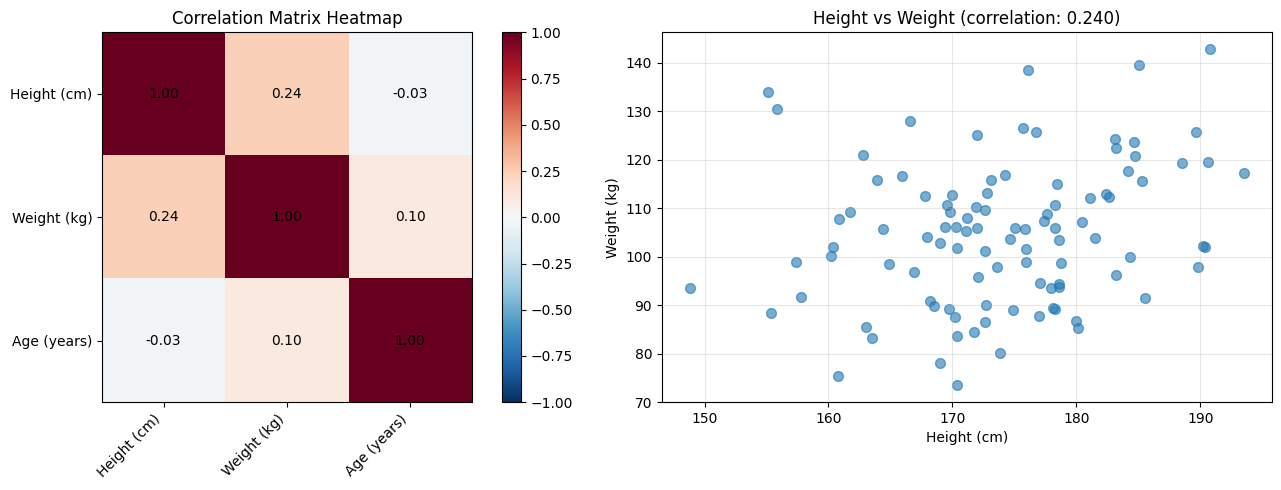


The scatter plot shows a positive correlation between height and weight!


In [5]:
# Visualize correlation matrix as a heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap of correlation matrix
im1 = axes[0].imshow(Corr, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_xticks(range(len(variable_names)))
axes[0].set_yticks(range(len(variable_names)))
axes[0].set_xticklabels(variable_names, rotation=45, ha='right')
axes[0].set_yticklabels(variable_names)
axes[0].set_title('Correlation Matrix Heatmap')

# Add correlation values to cells
for i in range(len(variable_names)):
    for j in range(len(variable_names)):
        text = axes[0].text(j, i, f'{Corr[i, j]:.2f}',
                            ha='center', va='center', color='black', fontsize=10)

plt.colorbar(im1, ax=axes[0])

# Scatter plot showing correlation
axes[1].scatter(X[:, 0], X[:, 1], alpha=0.6, s=50)
axes[1].set_xlabel(variable_names[0])
axes[1].set_ylabel(variable_names[1])
axes[1].set_title(f'Height vs Weight (correlation: {Corr[0,1]:.3f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nThe scatter plot shows a positive correlation between height and weight!")

## **2. Geometric Transformations via Matrix-Vector Multiplication**

One of the most elegant applications of linear algebra is using matrices to perform geometric transformations. When we think of a vector as representing a point or direction in space, multiplying the vector by a matrix transforms its position, orientation, and scale. This principle underlies computer graphics, robotics, image processing, and many other fields.

Key transformation types include:
- **Rotation**: Changes the direction of a vector without changing its magnitude
- **Scaling**: Multiplies the magnitude of a vector
- **Shearing**: Slants the coordinate system
- **Reflection**: Mirrors a vector across an axis or plane

### **2.1 2D Rotation Matrices**

A rotation matrix in 2D that rotates a vector counterclockwise by angle θ is:

R(θ) = [cos(θ)  -sin(θ)]
       [sin(θ)   cos(θ)]

The key properties are:
- Rotation matrices are orthogonal: R^T R = I
- Their determinant is 1: det(R) = 1
- Successive rotations multiply: R(θ₁) R(θ₂) = R(θ₁ + θ₂)

Original vector: [1 0]
Magnitude: 1.0000
Rotated 30°: [0.8660254 0.5      ], Magnitude: 1.0000
Rotated 45°: [0.70710678 0.70710678], Magnitude: 1.0000
Rotated 90°: [6.123234e-17 1.000000e+00], Magnitude: 1.0000
Rotated 180°: [-1.0000000e+00  1.2246468e-16], Magnitude: 1.0000


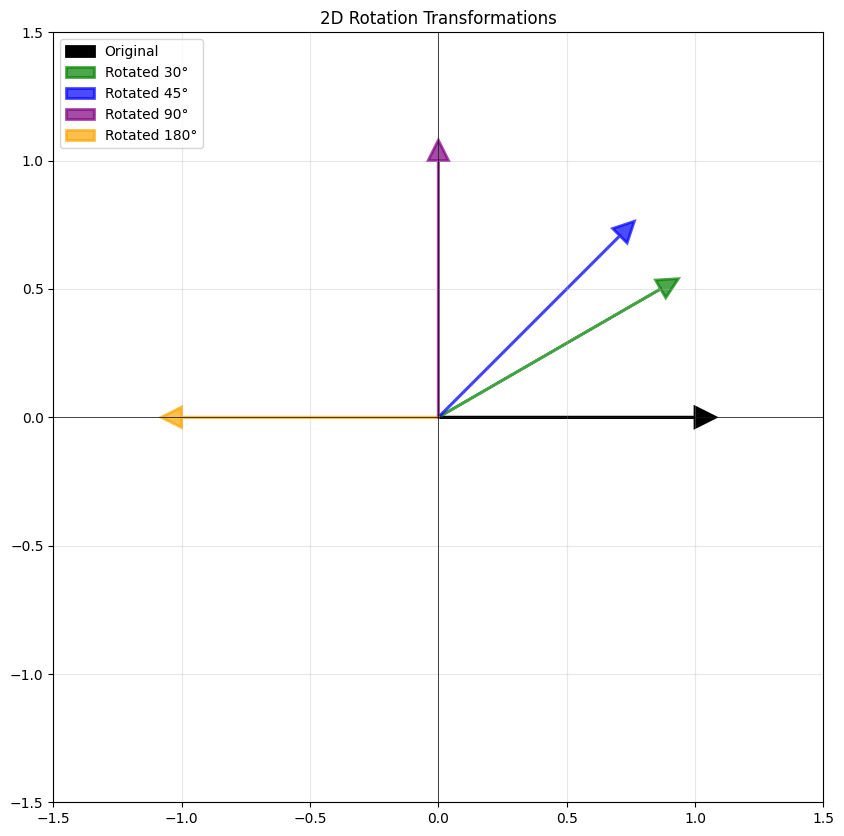


Note: Rotation preserves magnitude (length) of vectors!


In [6]:
# Create rotation matrix
def rotation_matrix(theta):
    """Create a 2D rotation matrix for angle theta (in radians)"""
    return np.array([[np.cos(theta), -np.sin(theta)],
                     [np.sin(theta), np.cos(theta)]])

# Original vector
v = np.array([1, 0])  # Unit vector pointing right
print(f"Original vector: {v}")
print(f"Magnitude: {np.linalg.norm(v):.4f}")

# Create rotation matrices for different angles
angles = [0, np.pi/6, np.pi/4, np.pi/2, np.pi]  # 0°, 30°, 45°, 90°, 180°
angle_degrees = [0, 30, 45, 90, 180]

fig, ax = plt.subplots(figsize=(10, 10))

# Plot original vector
ax.arrow(0, 0, v[0], v[1], head_width=0.08, head_length=0.08, fc='black', ec='black', linewidth=2, label='Original')

# Plot rotated vectors
colors = ['red', 'green', 'blue', 'purple', 'orange']
for angle, angle_deg, color in zip(angles[1:], angle_degrees[1:], colors[1:]):
    R = rotation_matrix(angle)
    v_rotated = R @ v
    ax.arrow(0, 0, v_rotated[0], v_rotated[1], head_width=0.08, head_length=0.08,
             fc=color, ec=color, linewidth=2, alpha=0.7, label=f'Rotated {angle_deg}°')
    print(f"Rotated {angle_deg}°: {v_rotated}, Magnitude: {np.linalg.norm(v_rotated):.4f}")

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.legend(loc='upper left')
ax.set_title('2D Rotation Transformations')
plt.show()

print("\nNote: Rotation preserves magnitude (length) of vectors!")

In [7]:
# Verify properties of rotation matrices
print("ROTATION MATRIX PROPERTIES")
print("=" * 60)

theta = np.pi / 4  # 45 degrees
R = rotation_matrix(theta)

print(f"\nRotation matrix for {np.degrees(theta):.1f}°:")
print(R)

print(f"\n1. Orthogonality: R^T @ R = I")
print(f"R^T @ R = \n{R.T @ R}")
print(f"Is identity: {np.allclose(R.T @ R, np.eye(2))}")

print(f"\n2. Determinant = 1")
print(f"det(R) = {np.linalg.det(R):.10f}")

print(f"\n3. Successive rotations: R(θ₁) @ R(θ₂) = R(θ₁ + θ₂)")
R1 = rotation_matrix(np.pi / 6)  # 30°
R2 = rotation_matrix(np.pi / 3)  # 60°
R_combined = R1 @ R2
R_direct = rotation_matrix(np.pi / 6 + np.pi / 3)  # 90°
print(f"R(30°) @ R(60°) equals R(90°): {np.allclose(R_combined, R_direct)}")

ROTATION MATRIX PROPERTIES

Rotation matrix for 45.0°:
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

1. Orthogonality: R^T @ R = I
R^T @ R = 
[[ 1.00000000e+00 -1.01465364e-17]
 [-1.01465364e-17  1.00000000e+00]]
Is identity: True

2. Determinant = 1
det(R) = 1.0000000000

3. Successive rotations: R(θ₁) @ R(θ₂) = R(θ₁ + θ₂)
R(30°) @ R(60°) equals R(90°): True


SCALING TRANSFORMATIONS

Original vector: [1 1]
Uniform scaling (2, 2): [1 1] → [2 2]
Non-uniform scaling (3, 1): [1 1] → [3 1]
Reflection (-1, 1): [1 1] → [-1  1]


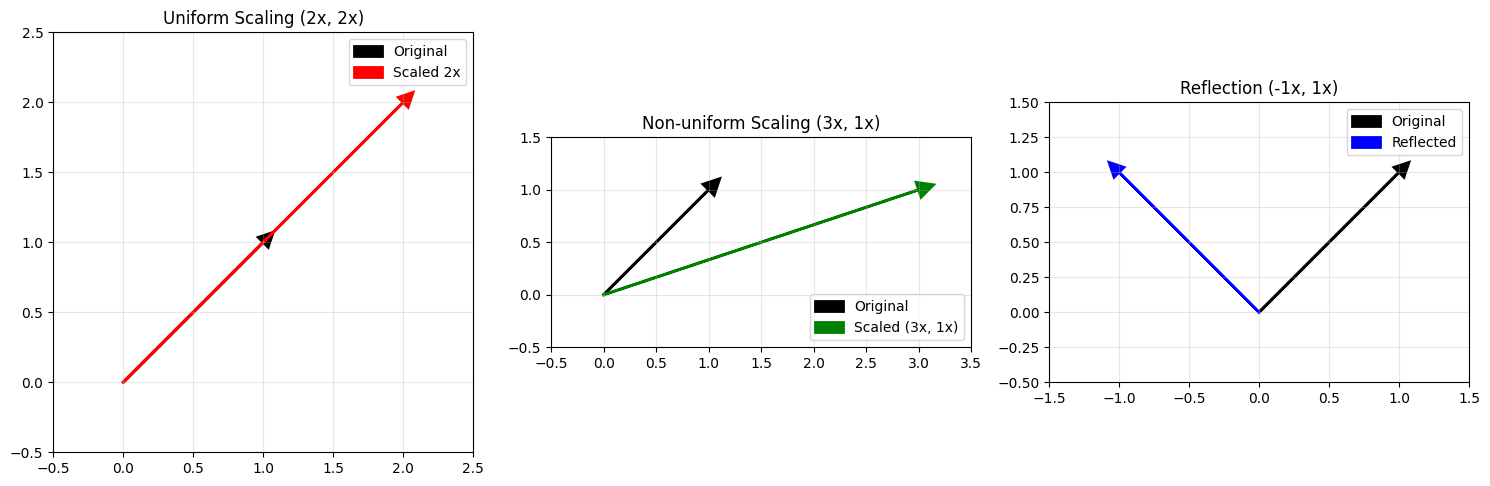

In [8]:
# Scaling transformation
print("SCALING TRANSFORMATIONS")
print("=" * 60)

# Scaling matrix: S = [sx  0]
#                     [0  sy]

def scaling_matrix(sx, sy):
    return np.diag([sx, sy])

v = np.array([1, 1])
print(f"\nOriginal vector: {v}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Example 1: Uniform scaling (scale equally in both directions)
S_uniform = scaling_matrix(2, 2)
v_scaled = S_uniform @ v
axes[0].arrow(0, 0, v[0], v[1], head_width=0.1, head_length=0.1, fc='black', ec='black', linewidth=2, label='Original')
axes[0].arrow(0, 0, v_scaled[0], v_scaled[1], head_width=0.1, head_length=0.1, fc='red', ec='red', linewidth=2, label='Scaled 2x')
axes[0].set_xlim(-0.5, 2.5)
axes[0].set_ylim(-0.5, 2.5)
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].set_title('Uniform Scaling (2x, 2x)')
print(f"Uniform scaling (2, 2): {v} → {v_scaled}")

# Example 2: Non-uniform scaling (different factors)
S_non_uniform = scaling_matrix(3, 1)
v_scaled = S_non_uniform @ v
axes[1].arrow(0, 0, v[0], v[1], head_width=0.15, head_length=0.15, fc='black', ec='black', linewidth=2, label='Original')
axes[1].arrow(0, 0, v_scaled[0], v_scaled[1], head_width=0.15, head_length=0.15, fc='green', ec='green', linewidth=2, label='Scaled (3x, 1x)')
axes[1].set_xlim(-0.5, 3.5)
axes[1].set_ylim(-0.5, 1.5)
axes[1].set_aspect('equal')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_title('Non-uniform Scaling (3x, 1x)')
print(f"Non-uniform scaling (3, 1): {v} → {v_scaled}")

# Example 3: Reflection (negative scaling)
S_reflect = scaling_matrix(-1, 1)
v_reflected = S_reflect @ v
axes[2].arrow(0, 0, v[0], v[1], head_width=0.1, head_length=0.1, fc='black', ec='black', linewidth=2, label='Original')
axes[2].arrow(0, 0, v_reflected[0], v_reflected[1], head_width=0.1, head_length=0.1, fc='blue', ec='blue', linewidth=2, label='Reflected')
axes[2].set_xlim(-1.5, 1.5)
axes[2].set_ylim(-0.5, 1.5)
axes[2].set_aspect('equal')
axes[2].grid(True, alpha=0.3)
axes[2].legend()
axes[2].set_title('Reflection (-1x, 1x)')
print(f"Reflection (-1, 1): {v} → {v_reflected}")

plt.tight_layout()
plt.show()

## **3. Image Feature Detection**

Image feature detection is a fundamental task in computer vision. Features like edges, corners, and textures can be detected using convolution operations, where a small matrix (called a kernel or filter) is slid across an image and convolved with local image patches. This is a matrix-vector multiplication applied repeatedly across spatial positions.

The convolution of an image I with a kernel K at position (i, j) is:

Output[i, j] = ∑ₘ ∑ₙ K[m, n] × I[i+m, j+n]

Common feature detection kernels include:
- **Sobel operator**: Detects edges by computing image gradients
- **Laplacian**: Detects intensity changes and edges
- **Gaussian blur**: Smooths images

### **3.1 Edge Detection using Sobel Operator**

The Sobel operator uses two 3×3 kernels to detect edges in horizontal and vertical directions. These kernels approximate the partial derivatives of the image intensity.

Image shape: (100, 100)

Sobel X kernel (horizontal edge detection):
[[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]

Sobel Y kernel (vertical edge detection):
[[-1. -2. -1.]
 [ 0.  0.  0.]
 [ 1.  2.  1.]]


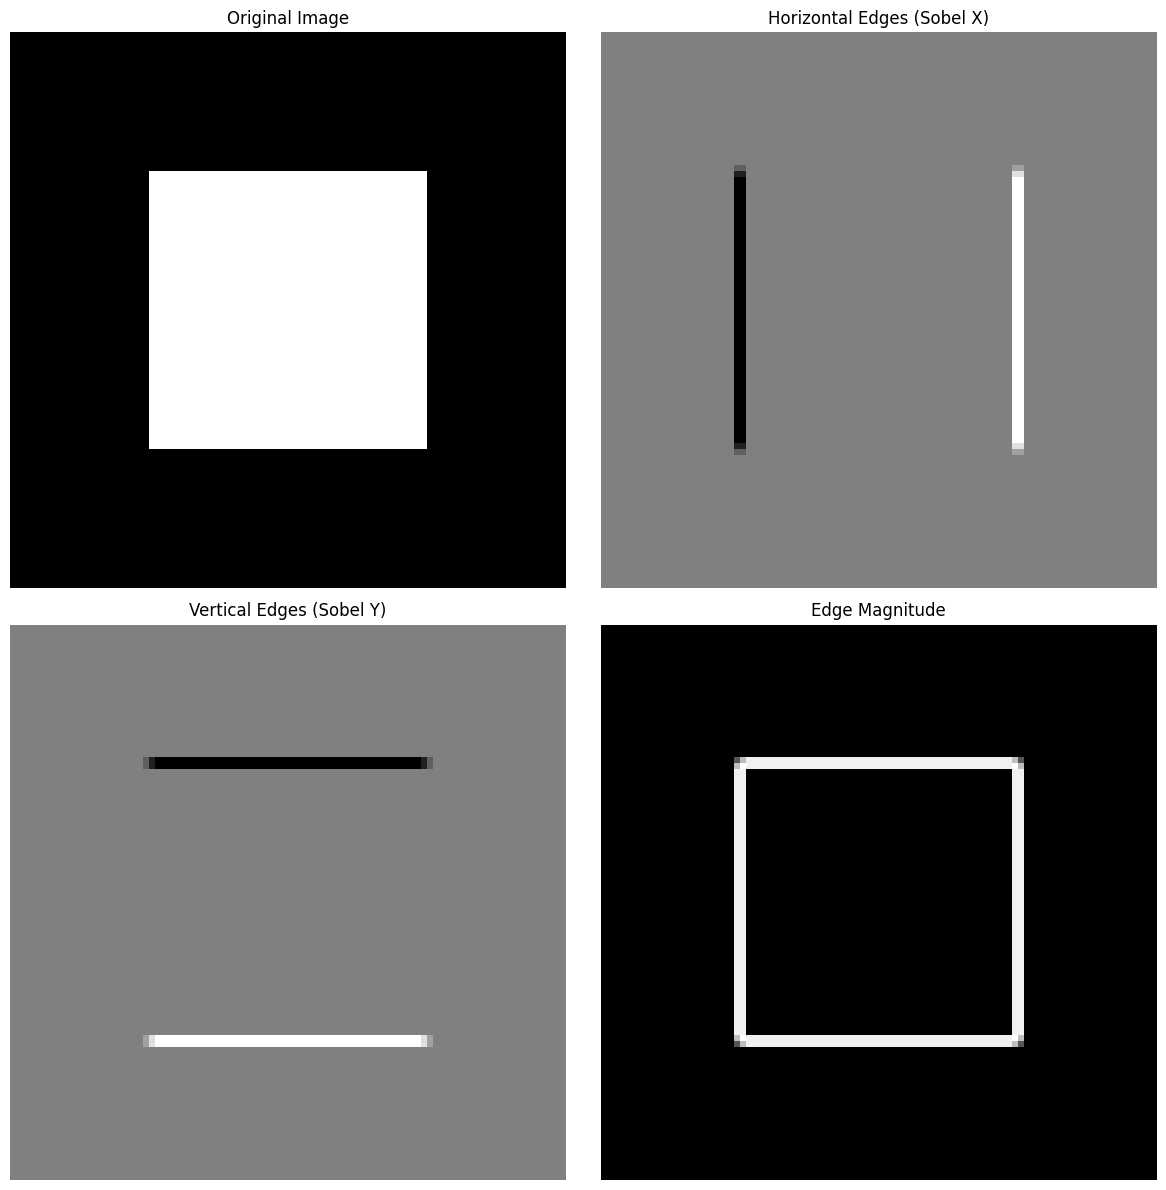

In [9]:
# Create a simple test image with edges
image_size = 100
image = np.zeros((image_size, image_size))
image[25:75, 25:75] = 255  # White square in the middle

print(f"Image shape: {image.shape}")

# Define Sobel operators (kernels)
sobel_x = np.array([[-1, 0, 1],
                     [-2, 0, 2],
                     [-1, 0, 1]], dtype=float)

sobel_y = np.array([[-1, -2, -1],
                     [0,  0,  0],
                     [1,  2,  1]], dtype=float)

print(f"\nSobel X kernel (horizontal edge detection):")
print(sobel_x)
print(f"\nSobel Y kernel (vertical edge detection):")
print(sobel_y)

# Apply convolution using scipy
from scipy.signal import convolve2d

edges_x = convolve2d(image, sobel_x, mode='same')
edges_y = convolve2d(image, sobel_y, mode='same')

# Compute edge magnitude
edges_magnitude = np.sqrt(edges_x**2 + edges_y**2)

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(edges_x, cmap='gray')
axes[0, 1].set_title('Horizontal Edges (Sobel X)')
axes[0, 1].axis('off')

axes[1, 0].imshow(edges_y, cmap='gray')
axes[1, 0].set_title('Vertical Edges (Sobel Y)')
axes[1, 0].axis('off')

axes[1, 1].imshow(edges_magnitude, cmap='gray')
axes[1, 1].set_title('Edge Magnitude')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

In [10]:
# Demonstrate convolution step-by-step
print("CONVOLUTION OPERATION EXPLANATION")
print("=" * 70)

# Create a small example
small_image = np.array([[100, 100, 100],
                       [100, 150, 100],
                       [100, 100, 100]], dtype=float)

small_kernel = np.array([[-1, 0, 1],
                        [-2, 0, 2],
                        [-1, 0, 1]], dtype=float)

print(f"\nSmall image (3x3):")
print(small_image)
print(f"\nKernel (3x3):")
print(small_kernel)

# Manual convolution at center position
convolution_sum = np.sum(small_image * small_kernel)
print(f"\nManual convolution at center:")
print(f"Element-wise multiplication and sum:")
print(small_image * small_kernel)
print(f"\nSum of products: {convolution_sum:.0f}")

print(f"\nThis demonstrates that convolution is a weighted sum (dot product)")
print(f"of the image patch with the kernel at each position.")

CONVOLUTION OPERATION EXPLANATION

Small image (3x3):
[[100. 100. 100.]
 [100. 150. 100.]
 [100. 100. 100.]]

Kernel (3x3):
[[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]

Manual convolution at center:
Element-wise multiplication and sum:
[[-100.    0.  100.]
 [-200.    0.  200.]
 [-100.    0.  100.]]

Sum of products: 0

This demonstrates that convolution is a weighted sum (dot product)
of the image patch with the kernel at each position.


## **4. Summary**

This chapter has demonstrated three powerful applications of linear algebra to real-world problems:

**Covariance and Correlation Matrices**: These are fundamental tools for understanding relationships between variables in multivariate data. The elegant matrix formulation Cov = (1/(m-1)) A^T A allows us to compute all pairwise covariances simultaneously through a single matrix multiplication. This principle underlies principal component analysis, factor analysis, and numerous machine learning algorithms.

**Geometric Transformations**: Matrices provide a compact and efficient way to represent and apply geometric transformations. Rotation matrices are orthogonal with determinant 1, scaling matrices are diagonal, and compositions of transformations correspond to matrix multiplication. These concepts are fundamental to computer graphics, robotics, and image processing.

**Image Feature Detection**: Convolution operations, which are fundamentally repeated matrix-vector multiplications, allow us to detect features like edges in images. The Sobel operator and other kernels demonstrate how linear algebra operations can extract meaningful information from high-dimensional data like images.

These applications showcase why matrix operations are so prevalent in data science: they provide a mathematical framework that is both theoretically elegant and computationally efficient. The next chapters will introduce even more advanced matrix operations—inverses and decompositions—that build on these foundations.